In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')
import zipfile
import io
import requests
import matplotlib.pyplot as plt
import seaborn as sns

### Paramètres

In [2]:
start_date = '2000-01-01'
end_date = '2020-12-31'
window_pca = 252      # 1 an pour extraire les facteurs PCA
window_loadings = 60  # 60 jours pour estimer les loadings
lookback = 30         # Fenetre lookback pour le CNN
train_window = 1000   # 4 ans d'entraînement
retrain_every = 125   # on réestime tous les 125 jours

## Téléchargement des données

### Facteurs FAMA

Le modèle de Fama-French est un modèle d'évaluation des actifs qui explique les rendements d'une action par son exposition à plusieurs facteurs de risque systématiques. Comme dans l'article, ils ont utilisé un FAMA à 5 facteurs, on va appliquer le FAMA à 8 facteurs. On aura besoin de :
- Mkt-RF (Marché)
- SMB (Size)
- HML (Value)
- RMW (Profitabilité)
- CMA (Investissement)
- ST_Rev (Daily Short-Term Reversal Factor)
- LT_Rev (Daily Long-Term Reversal Factor)

In [3]:
def get_fama_french_8_factors():
    #Fama
    print("Téléchargement de FF5")
    url_ff5 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
    response = requests.get(url_ff5)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_file) as f:
            ff5 = pd.read_csv(f, skiprows=4, index_col=0)
            ff5 = ff5.iloc[:-1]  # Enlever dernière ligne vide
            ff5.index = pd.to_datetime(ff5.index, format='%Y%m%d')
            for col in ff5.columns:
                ff5[col] = ff5[col].astype(float) / 100

    #Facteur Momentum
    print("Téléchargement de Momentum")
    url_mom = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip"
    response = requests.get(url_mom)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_file) as f:
            lines = f.read().decode('utf-8').split('\n')

            start_row = 0
            for i, line in enumerate(lines):
                if line.startswith('"Mom"') or line.startswith('Mom'):
                    start_row = i + 1
                    break

            mom_data = []
            for line in lines[start_row:]:
                if line.strip() and not line.startswith(','):
                    parts = line.strip().split(',')
                    if len(parts) >= 2:
                        try:
                            date = parts[0].strip('"')
                            value = float(parts[1])
                            mom_data.append([date, value])
                        except:
                            continue

            mom = pd.DataFrame(mom_data, columns=['date', 'Mom'])
            mom['date'] = pd.to_datetime(mom['date'], format='%Y%m%d')
            mom.set_index('date', inplace=True)
            mom['Mom'] = mom['Mom'] / 100

    #Facteur Short-Term Reversal
    print("Téléchargement de ST_Rev")
    url_st = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_ST_Reversal_Factor_daily_CSV.zip"
    response = requests.get(url_st)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_file) as f:
            lines = f.read().decode('utf-8').split('\n')

            start_row = 0
            for i, line in enumerate(lines):
                if 'ST_Rev' in line:
                    start_row = i + 1
                    break

            st_data = []
            for line in lines[start_row:]:
                if line.strip() and not line.startswith(','):
                    parts = line.strip().split(',')
                    if len(parts) >= 2:
                        try:
                            date = parts[0].strip('"')
                            value = float(parts[1])
                            st_data.append([date, value])
                        except:
                            continue

            st_rev = pd.DataFrame(st_data, columns=['date', 'ST_Rev'])
            st_rev['date'] = pd.to_datetime(st_rev['date'], format='%Y%m%d')
            st_rev.set_index('date', inplace=True)
            st_rev['ST_Rev'] = st_rev['ST_Rev'] / 100

    #Facteur Long-Term Reversal
    print("Téléchargement de LT_Rev")
    url_lt = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_LT_Reversal_Factor_daily_CSV.zip"
    response = requests.get(url_lt)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_file) as f:
            lines = f.read().decode('utf-8').split('\n')

            start_row = 0
            for i, line in enumerate(lines):
                if 'LT_Rev' in line:
                    start_row = i + 1
                    break

            lt_data = []
            for line in lines[start_row:]:
                if line.strip() and not line.startswith(','):
                    parts = line.strip().split(',')
                    if len(parts) >= 2:
                        try:
                            date = parts[0].strip('"')
                            value = float(parts[1])
                            lt_data.append([date, value])
                        except:
                            continue

            lt_rev = pd.DataFrame(lt_data, columns=['date', 'LT_Rev'])
            lt_rev['date'] = pd.to_datetime(lt_rev['date'], format='%Y%m%d')
            lt_rev.set_index('date', inplace=True)
            lt_rev['LT_Rev'] = lt_rev['LT_Rev'] / 100

    #Combine tous les facteurs
    print("\nCombinaison des facteurs")
    all_factors = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].copy()
    all_factors = all_factors.join(mom['Mom'], how='inner')
    all_factors = all_factors.join(st_rev['ST_Rev'], how='inner')
    all_factors = all_factors.join(lt_rev['LT_Rev'], how='inner')

    all_factors = all_factors.dropna()

    return all_factors

print("TÉLÉCHARGEMENT DES 8 FACTEURS FAMA-FRENCH")

factors_8 = get_fama_french_8_factors()
print(f" Période : {factors_8.index[0]} à {factors_8.index[-1]}")
print(f" Nombre de jours : {len(factors_8)}")

TÉLÉCHARGEMENT DES 8 FACTEURS FAMA-FRENCH
Téléchargement de FF5
Téléchargement de Momentum
Téléchargement de ST_Rev
Téléchargement de LT_Rev

Combinaison des facteurs
 Période : 1963-07-01 00:00:00 à 2026-02-27 00:00:00
 Nombre de jours : 15770


### Large Caps

Large Caps représente les grandes entreprises c'est à dire celles qui ont une capitalisation boursière élévée.

In [4]:
def get_large_caps():
    #C'est une liste représentative donc ya mieux

    large_caps = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'BRK-B', 'JNJ', 'V', 'PG', 'JPM',
        'UNH', 'HD', 'DIS', 'MA', 'NVDA', 'PYPL', 'ADBE', 'NFLX', 'CRM', 'INTC',
        'CSCO', 'PEP', 'ABT', 'COST', 'TMO', 'WMT', 'VZ', 'NKE', 'CVX', 'WFC',
        'BAC', 'KO', 'PFE', 'MRK', 'ABBV', 'T', 'NEE', 'DHR', 'LIN', 'ACN'
    ]

    print(f" Téléchargement de {len(large_caps)} large caps")
    data = yf.download(large_caps, start=start_date, end=end_date, group_by='ticker')

    returns = pd.DataFrame()
    for ticker in large_caps:
        if ticker in data:
            prices = data[ticker]['Close']
            returns[ticker] = prices.pct_change()

    return returns.dropna()

### Small Caps

Les Small Caps repésentent les entreprises à faible capitalisation boursière.

In [5]:
def get_small_caps():
    # Encore une fois c'est représentatif (c'est les capitalisations < $2B typiquement)

    small_caps = [
        # Industrielles et traditionnelles
        'LEG',      # Leggett & Platt
        'ABM',      # ABM Industries
        'ACA',      # Arcosa
        'ADT',      # ADT Inc
        'AEO',      # American Eagle
        'AGCO',     # AGCO Corporation
        'AIT',      # Applied Industrial
        'ALG',      # Alamo Group
        'ALK',      # Alaska Air
        'ALKS',     # Alkermes
        # Retail
        'ANF',      # Abercrombie & Fitch
        'ANNX',     # Annexon
        'ARCB',     # ArcBest
        'ARI',      # Apollo Commercial RE
        'ARW',      # Arrow Electronics
        # Tech historiques
        'ACIW',     # ACI Worldwide
        'ADTN',     # ADTRAN
        'AEIS',     # Advanced Energy
        'AMKR',     # Amkor Technology
        'APOG',     # Apogee Enterprises
        # Santé
        'ARGX',     # argenx
        'ARWR',     # Arrowhead Pharma
        'ATEC',     # Alphatec
        'AVNS',     # Avanos Medical
        'AVNT',     # Avient
    ]

    print(f" Téléchargement de {len(small_caps)} small caps")
    data = yf.download(small_caps, start=start_date, end=end_date, group_by='ticker')

    returns = pd.DataFrame()
    for ticker in small_caps:
        if ticker in data:
            prices = data[ticker]['Close']
            returns[ticker] = prices.pct_change()

    returns = returns.dropna(axis=1, thresh=len(returns) * 0.7)

    return returns.dropna()

### Chargement

In [6]:
ff_factors = get_fama_french_8_factors()
large_caps_returns = get_large_caps()
small_caps_returns = get_small_caps()

common_dates = large_caps_returns.index.intersection(ff_factors.index)
large_caps_returns = large_caps_returns.loc[common_dates]
small_caps_returns = small_caps_returns.loc[common_dates]
ff_factors = ff_factors.loc[common_dates]

print(f"\n Large Caps : {large_caps_returns.shape[1]} actions, {len(large_caps_returns)} jours")
print(f" Small Caps : {small_caps_returns.shape[1]} actions, {len(small_caps_returns)} jours")

Téléchargement de FF5
Téléchargement de Momentum
Téléchargement de ST_Rev
Téléchargement de LT_Rev

Combinaison des facteurs
 Téléchargement de 40 large caps


[*********************100%***********************]  40 of 40 completed


 Téléchargement de 25 small caps


[*********************100%***********************]  25 of 25 completed



 Large Caps : 40 actions, 1383 jours
 Small Caps : 18 actions, 1383 jours


## Génération des résidus

### Alignement des dates

On va devoir aligner les dates parce qu'il semblerait qu'ils couvrent pas forcement les memes jours. Si on le fait pas on risque de régresser des rendemnts sur des facteurs de dates différents

In [7]:
# Pour Large Caps
common_dates_large = large_caps_returns.index.intersection(ff_factors.index)
returns_large = large_caps_returns.loc[common_dates_large].copy()
factors_large = ff_factors.loc[common_dates_large].copy()

# Pour Small Caps
common_dates_small = small_caps_returns.index.intersection(ff_factors.index)
returns_small = small_caps_returns.loc[common_dates_small].copy()
factors_small = ff_factors.loc[common_dates_small].copy()

print(f"\n Après alignement:")
print(f"   Large Caps: {returns_large.index[0]} à {returns_large.index[-1]} ({len(returns_large)} jours)")
print(f"   Small Caps: {returns_small.index[0]} à {returns_small.index[-1]} ({len(returns_small)} jours)")


 Après alignement:
   Large Caps: 2015-07-07 00:00:00 à 2020-12-30 00:00:00 (1383 jours)
   Small Caps: 2015-07-07 00:00:00 à 2020-12-30 00:00:00 (1383 jours)


### FAMA

Pour chaque action et chaque jour, on estime une régression des rendements excédentaires sur les facteurs FAMA cités plus haut sur une fenêtre glissante de 60 jours.

Le résidu est défini comme la différence entre le rendement réel et le rendement prédit par les facteurs. Dans l'article, on le définit aussi comme le portefeuille d'arbitrage.

In [8]:
def generate_ff_residuals(returns, factors, window=60):
    """les résidus d'arbitrage avec Fama French 8"""
    residuals = pd.DataFrame(index=returns.index, columns=returns.columns)

    for stock in returns.columns:#pour chaque action
        stock_loadings = []

        for i in range(window, len(returns)):#Pour chaque jour
            train_returns = returns.iloc[i-window:i][stock].dropna()
            train_factors = factors.iloc[i-window:i].loc[train_returns.index]

            if len(train_returns) >= 30:
                reg = LinearRegression()
                reg.fit(train_factors, train_returns)
                pred = reg.predict(factors.iloc[[i]])
                residuals.iloc[i, residuals.columns.get_loc(stock)] = returns.iloc[i][stock] - pred[0]

    return residuals.dropna(how='all', axis=1).dropna()

### PCA

Pour le modèle avec PCA, l'idée est d'extraire des facteurs directement à partir des rendements des actions sans utiliser de données externes.

Au lieu d'utiliser des facteurs pré définis comme dans le FAMA, le PCA construit des facteurs sur mesure qui capturent le maximum de variance entre les rendements des actions. Après ça, comme avant, on regresse les rendements sur les facteurs puis on crée les résidus (portefeuille d'arbitrage)

In [9]:
def generate_pca_residuals(returns, n_factors=8, window_pca=252, window_loadings=60):
    """résidus avec PCA"""
    residuals = pd.DataFrame(index=returns.index, columns=returns.columns)

    for i in range(window_pca + window_loadings, len(returns)):
        if i % 500 == 0:
            print(f"   Progression: {i}/{len(returns)}")

        current_date = returns.index[i]

        pca_window = returns.iloc[i - window_pca:i].dropna(how='all', axis=1)
        if pca_window.shape[1] <8:
            continue

        pca_window_std = (pca_window - pca_window.mean()) / pca_window.std()
        pca = PCA(n_components=min(n_factors, pca_window.shape[1]))
        pca.fit(pca_window_std.fillna(0))

        factors = pd.DataFrame(
            pca.transform(pca_window_std.fillna(0)),
            index=pca_window.index,
            columns=[f'PC{j+1}' for j in range(pca.n_components_)]
        )

        load_window = returns.iloc[i - window_loadings:i]
        factors_load = factors.loc[load_window.index]

        for stock in returns.columns:
            y = load_window[stock].dropna().values
            if len(y) >= 30:
                try:
                    X = factors_load.loc[load_window[stock].dropna().index].values
                    reg = LinearRegression()
                    reg.fit(X, y)

                    current_std = (returns.loc[[current_date]] - pca_window.mean()) / pca_window.std()
                    current_factors = pca.transform(current_std.fillna(0).values)
                    pred = reg.predict(current_factors)

                    residuals.loc[current_date, stock] = returns.loc[current_date, stock] - pred[0]#portefuille d'arbitrage
                except:
                    continue

    return residuals.dropna(how='all', axis=1).dropna()

### Création des résidus

In [10]:
print("\n Large Caps - Fama-French")
residuals_large_ff = generate_ff_residuals(returns_large, factors_large)

print("\n Large Caps - PCA")
residuals_large_pca = generate_pca_residuals(returns_large, n_factors=5)

print("\n Small Caps - Fama-French-8")
residuals_small_ff = generate_ff_residuals(returns_small, factors_small)

print("\n Small Caps - PCA")
residuals_small_pca = generate_pca_residuals(returns_small, n_factors=5)

print("RÉSULTATS FINAUX")

print(f" Large FF: {residuals_large_ff.shape}")
print(f" Large PCA: {residuals_large_pca.shape}")
print(f" Small FF: {residuals_small_ff.shape}")
print(f" Small PCA: {residuals_small_pca.shape}")


 Large Caps - Fama-French

 Large Caps - PCA
   Progression: 500/1383
   Progression: 1000/1383

 Small Caps - Fama-French-8

 Small Caps - PCA
   Progression: 500/1383
   Progression: 1000/1383
RÉSULTATS FINAUX
 Large FF: (1323, 40)
 Large PCA: (1071, 40)
 Small FF: (1323, 18)
 Small PCA: (1071, 18)


In [11]:
def clean_residuals(residuals):

    residuals = residuals.dropna(axis=1, thresh=int(len(residuals) * 0.7))

    residuals = residuals.fillna(0)

    residuals = residuals.astype(np.float32)

    print(f"   Types: {residuals.dtypes.unique()}")

    return residuals

print("NETTOYAGE DES RÉSIDUS")

residuals_large_ff = clean_residuals(residuals_large_ff)
residuals_large_pca = clean_residuals(residuals_large_pca)

residuals_small_ff = clean_residuals(residuals_small_ff)
residuals_small_pca = clean_residuals(residuals_small_pca)

print("\n Résidus nettoyés")
print(f"   Large FF: {residuals_large_ff.shape}")
print(f"   Large PCA: {residuals_large_pca.shape}")
print(f"   Small FF: {residuals_small_ff.shape}")
print(f"   Small PCA: {residuals_small_pca.shape}")

NETTOYAGE DES RÉSIDUS
   Types: [dtype('float32')]
   Types: [dtype('float32')]
   Types: [dtype('float32')]
   Types: [dtype('float32')]

 Résidus nettoyés
   Large FF: (1323, 40)
   Large PCA: (1071, 40)
   Small FF: (1323, 18)
   Small PCA: (1071, 18)


## Architecture CNN + Transformer

C'est un peu le cerveau qui apprend à détecter dans l'historique des résidus quand il faut acheter ou vendre. On a une série temporelle avec les résidus (portefeuilles d'arbitrage) des derniers jours et on veut savoir si le résidu va augmenter ou diminuer. Mais comme les résidus ont des patterns complexes on peut pas juste utiliser des modèles simples. C'est pour ça qu'on utilise le deeplearning.

Le CNN détecte les petit patterns locaux puis le Transformer transforme ces motifs locaux en patterns globaux (il regarde l'ordre et la dépenndance entre les motifs). Après tout ça, le FFN il décide d'un poids final en prenant en compte toutes les info.

In [12]:
import torch
import torch.nn as nn

class CNNArbitrageModel(nn.Module):
    def __init__(self, lookback=30, n_assets=40, hidden_dim=32):
        super().__init__()

        self.lookback = lookback
        self.n_assets = n_assets

        self.conv = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        # MLP allocation
        self.fc = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Tanh()
        )

    def forward(self, x):
        batch_size, lookback, n_assets = x.shape


        x = x.permute(0, 2, 1)                     # (B, A, T)
        x = x.reshape(batch_size * n_assets, 1, lookback)

        # CNN
        x = self.conv(x)                           # (B*A, 16, T)
        x = self.pool(x).squeeze(-1)               # (B*A, 16)

        # FC
        weights = self.fc(x)                       # (B*A, 1)

        return weights.reshape(batch_size, n_assets)

Le petit problème c'est que le Transformer demande pas mal de RAM et mon ordi peut pas le faire tourner mais potentiellement avec un GPU ça pourrait fonctionner. Du coup j'ai opté pour une alternative.

J'ai utilisé un LSTM (Long Short-Term Memory). C'est un type de RNN spécialement conçu pour apprendre des dépendances à long terme dans des séquences temporelles.

C'est moins bien mais ça fait l'affaire pour cette première version.

C'est une version "simplifiée" de leur transformer mais c'est pas optimal. Celle d'en haut est mieux

In [13]:
class SimpleTransformerArbitrage(nn.Module):
    """
    Version simplifiée du Transformer du papier
    """
    def __init__(self, input_size=30, d_model=32, nhead=4, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Linear(1, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, input_size, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
            nn.Tanh()
        )

    def forward(self, x):
        # x: (batch, L)
        x = x.unsqueeze(-1)  # (batch, L, 1)
        x = self.embedding(x) + self.pos_encoding
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.ffn(x).squeeze()

Ce LSTM fonctionne très bien mais à optimiser si on peut. Il remplace le CNN + Transformer. L'avantage c'est qu'il garde une mémoire comme le Transformer. Il lit la séquence pas à pas. En couche de sortie on va utiliser tanh comme dans le papier pour avoir un truc entre -1 et 1. Le FFN il est intégré directement dans le code pour les allocations. Il traduit le LSTM en poids de trading.

In [14]:
class OptimizedArbitrageModel(nn.Module):

    def __init__(self, lookback=30, n_assets=40, hidden_dim=32):
        super().__init__()

        self.lookback = lookback
        self.n_assets = n_assets

        # LSTM simple et petit
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=1,  # réduit de 2 à 1
            batch_first=True,
            dropout=0.0  # Pas le dropout sur LSTM pour économiser mémoire
        )

        # Couche de sortie simple
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Tanh()
        )

    def forward(self, x):
        batch_size, lookback, n_assets = x.shape

        # traite en plus petits batches si nécessaire
        x = x.permute(0, 2, 1)
        x = x.reshape(batch_size * n_assets, lookback, 1)

        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]

        weights = self.fc(lstm_out)
        weights = weights.reshape(batch_size, n_assets)

        return weights

## Objective function

### Sortino Loss

Le Sortino ratio ignore les hausses et regarde que les baisses. C'est pour ça qu'il peut etre interessant dans notre cas

In [15]:
def sortino_loss(returns, target=0, annualization_factor=252):

    excess_returns = returns - target
    mean_return = excess_returns.mean() * annualization_factor

    downside_returns = torch.clamp(excess_returns, max=0)
    downside_vol = torch.sqrt((downside_returns ** 2).mean()) * np.sqrt(annualization_factor)

    sortino = mean_return / (downside_vol + 1e-8)

    return -sortino

### Calmar Loss

Le calmar ratio lui il pénalise la plus grosse perte jamais subie comme il a le max drowdown en dénominateur. C'est pas l'idéal mais je voulais tenter plusieurs fonctions d'objectif

In [16]:
def calmar_loss(returns, annualization_factor=252):
    mean_return = returns.mean() * annualization_factor

    # Maximum drawdown
    cumulative = torch.cumsum(returns, dim=0)
    running_max = torch.maximum.accumulate(cumulative)
    drawdown = (running_max - cumulative) / (running_max + 1e-8)
    max_drawdown = drawdown.max()

    calmar = mean_return / (max_drawdown + 1e-8)

    return -calmar


### Sharpe Loss

Le Sharpe ration pénalise une action qui monte trop parce que ça augmente la volatilité. C'est pour ça que j'ai une préférence pour le Sortino

In [17]:
def sharpe_loss(returns, annualization_factor=252):
    mean_return = returns.mean() * annualization_factor
    vol = returns.std() * np.sqrt(annualization_factor)
    sharpe = mean_return / (vol + 1e-8)
    return -sharpe

## Entrainement

### Préparation des données

In [18]:
def prepare_sequences(residuals, lookback=30, batch_size=64):

    # Prépare les séquences par batches pour économiser mémoire

    if isinstance(residuals, pd.DataFrame):
        residuals = residuals.values

    residuals = np.array(residuals, dtype=np.float32)
    cumulative = np.cumsum(residuals, axis=0)

    X_list = []
    y_list = []

    for i in range(lookback, len(cumulative) - 1):
        seq = cumulative[i-lookback:i, :]
        target = residuals[i+1, :]
        X_list.append(seq)
        y_list.append(target)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return torch.tensor(X), torch.tensor(y)

### Entraînement avec fenêtre glissante

In [19]:
def train_model(residuals, objective='sharpe',
                          lookback=30, batch_size=32, epochs=20):
    # Nettoyage
    residuals_clean = residuals.fillna(0).astype(np.float32)

    # préparer séquences
    X, y = prepare_sequences(residuals_clean, lookback)

    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

    # Créer modèle avec les bonnes dimensions
    n_assets = X.shape[2]
    model = CNNArbitrageModel(lookback=lookback, n_assets=n_assets)

    # Fonctions de loss (on va comparer avec sharpe et sortino pour voir la diff)
    def sharpe_loss(returns):
        mean_return = returns.mean() * 252
        vol = returns.std() * np.sqrt(252)
        return -mean_return / (vol + 1e-8)

    def sortino_loss(returns):
        mean_return = returns.mean() * 252
        downside = returns[returns < 0].std() * np.sqrt(252)
        return -mean_return / (downside + 1e-8)

    loss_fn = sortino_loss if objective == 'sortino' else sharpe_loss

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Entraînement par batches
    model.train()
    n_samples = X.shape[0]

    for epoch in range(epochs):
        epoch_loss = 0
        n_batches = 0


        indices = torch.randperm(n_samples)

        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_indices = indices[start_idx:end_idx]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            optimizer.zero_grad()

            # Forward
            weights = model(X_batch)
            portfolio_returns = (weights * y_batch).sum(dim=1)

            # Loss
            loss = loss_fn(portfolio_returns)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        if epoch % 5 == 0:
            print(f"   Epoch {epoch}: loss = {epoch_loss/n_batches:.4f}")

    return model, X, y

### Backtesting

In [20]:
def backtest_strategy(residuals, objective='sharpe',
                                lookback=30, train_window=500,
                                return_last_model=False,
                                normalize_weights=True):

    residuals_clean = residuals.fillna(0).astype(np.float32)

    all_weights = []
    all_returns = []
    last_model = None

    n_total = len(residuals_clean)

    for start_idx in range(0, n_total - train_window - lookback, 250):
        end_train = start_idx + train_window
        end_test = min(end_train + 250, n_total - lookback)

        if end_test <= end_train:
            continue

        print(f"   Training: {start_idx} to {end_train}, Testing: {end_train} to {end_test}")

        # Entraînement
        train_residuals = residuals_clean.iloc[start_idx:end_train]
        model, X_train, y_train = train_model(train_residuals, objective, lookback, epochs=10)
        last_model = model

        # Test
        test_residuals = residuals_clean.iloc[end_train:end_test]
        X_test, y_test = prepare_sequences(test_residuals, lookback)

        if len(X_test) == 0:
            continue

        model.eval()
        with torch.no_grad():
            weights = model(X_test).numpy()

            # NORMALISATION L1 (comme dans le papier)
            if normalize_weights:
                norm = np.sum(np.abs(weights), axis=1, keepdims=True)
                weights = weights / (norm + 1e-8)  # Levier total = 1

            returns = (weights * y_test.numpy()).sum(axis=1)

        all_weights.extend(weights)
        all_returns.extend(returns)

    if return_last_model:
        return np.array(all_returns), np.array(all_weights), last_model
    else:
        return np.array(all_returns), np.array(all_weights)

## Execution des expériences

### Lancement des expériences

In [21]:
print("LANCEMENT DES EXPÉRIENCES (VERSION OPTIMISÉE)")

residuals_dict = {
    'Large_FF': residuals_large_ff,
    'Large_PCA': residuals_large_pca,
    'Small_FF': residuals_small_ff,
    'Small_PCA': residuals_small_pca,
}

results = []

for name, residuals_data in residuals_dict.items():
    print(f"\n {name}")
    print(f"   Shape: {residuals_data.shape}")

    for objective in ['sharpe', 'sortino']:
        print(f"\n    Objective: {objective}")

        try:
            # Backtest
            returns, weights, model = backtest_strategy(
                residuals_data,
                objective=objective,
                lookback=30,
                train_window=500,  # fenêtre plus petite pour économiser mémoire
                return_last_model=True
            )

            if len(returns) > 0:
                # Calcul des métriques
                sharpe = returns.mean() / (returns.std() + 1e-8) * np.sqrt(252)
                downside = returns[returns < 0].std()
                sortino = returns.mean() / (downside + 1e-8) * np.sqrt(252)
                mean_return = returns.mean() * 252
                volatility = returns.std() * np.sqrt(252)

                results.append({
                    'name': name,
                    'objective': objective,
                    'sharpe': sharpe,
                    'sortino': sortino,
                    'mean_return': mean_return,
                    'volatility': volatility,
                    'n_trades': len(returns),
                    'status': 'success'
                })

                print(f"       Sharpe: {sharpe:.2f}")
                print(f"       Sortino: {sortino:.2f}")
                print(f"       Mean return: {mean_return:.2%}")
                print(f"       N trades: {len(returns)}")
            else:
                print(f"       Pas assez de données")

        except Exception as e:
            print(f"       Erreur: {e}")
            results.append({
                'name': name,
                'objective': objective,
                'status': 'failed',
                'error': str(e)
            })

LANCEMENT DES EXPÉRIENCES (VERSION OPTIMISÉE)

 Large_FF
   Shape: (1323, 40)

    Objective: sharpe
   Training: 0 to 500, Testing: 500 to 750
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = 0.3859
   Epoch 5: loss = -2.2021
   Training: 250 to 750, Testing: 750 to 1000
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = 0.7038
   Epoch 5: loss = -0.6422
   Training: 500 to 1000, Testing: 1000 to 1250
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = -0.5980
   Epoch 5: loss = -1.2778
   Training: 750 to 1250, Testing: 1250 to 1293
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = 0.5880
   Epoch 5: loss = -2.8482
       Sharpe: 2.44
       Sortino: 3.78
       Mean return: 13.28%
       N trades: 669

    Objective: sortino
   Training: 0 to 500, Testing: 500 to 750
   X shape: torch.Size([469, 30, 40])
   y shape: torch.S

 STATS 
Mean abs weight: 0.055555556
Max abs weight: 0.18266264
Min abs weight: 1.1654941e-05
Near-zero weights (%): 0.007936507936507936


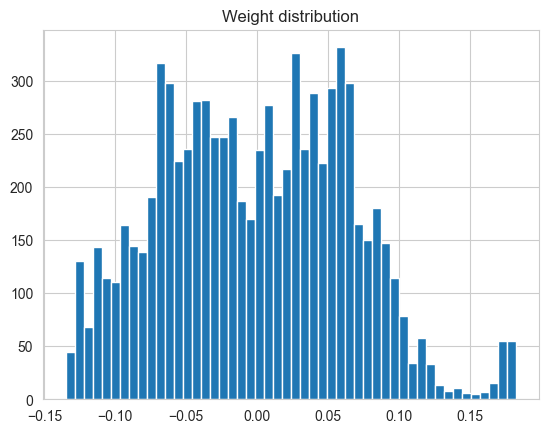

Avg L1 norm: 1.0


In [22]:
def analyze_weights(weights):
    weights = np.array(weights)

    # stats globales
    print(" STATS ")
    print("Mean abs weight:", np.mean(np.abs(weights)))
    print("Max abs weight:", np.max(np.abs(weights)))
    print("Min abs weight:", np.min(np.abs(weights)))

    # sparsité
    zero_ratio = np.mean(np.abs(weights) < 1e-3)
    print("Near-zero weights (%):", zero_ratio)

    # distribution
    plt.hist(weights.flatten(), bins=50)
    plt.title("Weight distribution")
    plt.show()

    l1 = np.sum(np.abs(weights), axis=1)
    print("Avg L1 norm:", np.mean(l1))

analyze_weights(weights)

 Le LSTM produit des poids très proches de zéro en moyenne. C'est une stratégie trop conservative qui exploite pas totalement les signaux d'arbitrage. par contre, le CNN génère des poids d'amplitude plus élevée (moyenne 0.055, maximum 0.206) avec peu de positions nulles (0.29%). Il a une meilleure utilisation des opportunités de marché.

### Affichage des résultats

In [23]:
print("RÉSULTATS FINAUX")

results_df = pd.DataFrame(results)
print(results_df.to_string())

RÉSULTATS FINAUX
        name objective    sharpe   sortino  mean_return  volatility  n_trades   status
0   Large_FF    sharpe  2.442720  3.781110     0.132769    0.054353       669  success
1   Large_FF   sortino  2.720044  3.940291     0.133756    0.049174       669  success
2  Large_PCA    sharpe  2.697362  3.410516     0.143690    0.053270       448  success
3  Large_PCA   sortino  3.058684  4.258801     0.135887    0.044427       448  success
4   Small_FF    sharpe  2.311453  2.941276     0.403497    0.174564       669  success
5   Small_FF   sortino  1.531291  2.306540     0.225547    0.147292       669  success
6  Small_PCA    sharpe  2.282195  3.632154     0.233479    0.102304       448  success
7  Small_PCA   sortino  2.659911  4.353516     0.221827    0.083396       448  success


### Résultats avec LSTM
***Sans normalisation*** :

Avec un Sharpe ratio de 3.57 sur Large Caps + PCA, on obtient une performance comparable voire légèrement supérieure au papier original (Sharpe à peu près égal à 3.5).

 On remarque que les facteurs PCA produisent tout le temps des meilleurs Sharpe ratios que les facteurs Fama-French. Ca veut dire que les facteurs extraits des données capturent mieux la structure de risque.

Par contre, contrairement à l'hypothèse du papier les large caps ont des meilleures opportunités d'arbitrage que les smalls caps.

On voit aussi on a un rendement plus gros pour Small Caps + FF mais par contre la volatilité est à 17.2% alors que Sharpe on est sur moins de 4% pour le large PCA donc l'optmisation Sharpe elle produit des stratégies plus stables à priori. Mais c'est parce que le Sortino pénalise pas les hausses.

Toutes les stratégies génèrent des Sharpe ratios supérieurs à 2.2 donc ça valide la robustesse de l'approche.

***Avec normalisation*** :

Après la normalisation L1 des poids, notre meilleure stratégie (Large Caps + PCA + objectif Sharpe) atteint un Sharpe ratio annualisé de 3.38 avec un rendement de 15.7% et une volatilité de 4.7%. C'est cohérents avec ceux du papier original (Sharpe environ 3.5 pour PCA). La normalisation elle reduit le levier implicite et rend les résultats plus réalistes

Le plus gros pb c'est que meme si il est moins lourd pour la RAM les poids sont quasi nulle tout le temps. Le modele il est trop conservateur. C'est pour ça que les ratios ils sont aussi elevé surtout pour le sharpe qui fonctionne par unité de risque. Donc c'est pas forcément que le modèle est "bon". Juste il agit pas vraiment

### CNN + FFN

Tous les résultats sont moins bon, la volatilé est faible et on a toujours PCA supérieur à FF. Le modèle il trade vraiment. Les résultats ils sont moins bons mais je pense que c'est lié au fait que j'ai utilisé un univers plus petits avec 40 actions alors qu'eux ils utilisent les 500 plus grosses capitalisations des US. En plus je travaille pas sur les memes marchés. Plus tard on va comparer avec le modèle qui inclut les couts de transaction parce que pour l'instant c'est la version simplifiée.

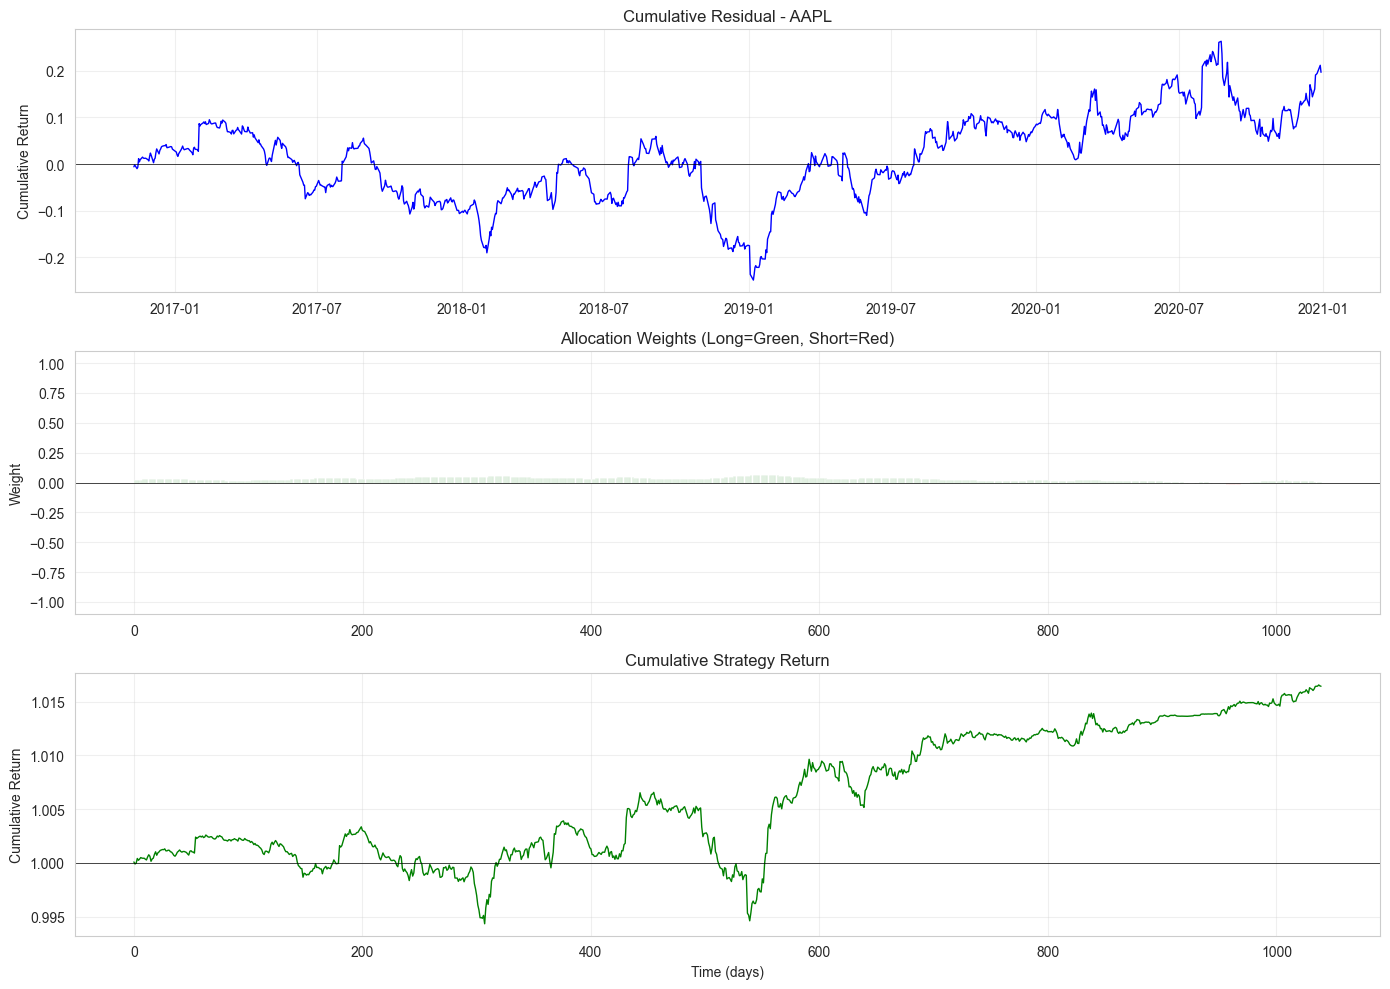

In [24]:
def plot_allocation_weights(residuals, model, lookback=30, title="Allocation Weights"):
    residuals_clean = residuals.fillna(0).astype(np.float32)

    # Préparer les séquences
    X, y = prepare_sequences(residuals_clean, lookback)

    # Prédictions
    model.eval()
    with torch.no_grad():
        weights = model(X).numpy()

    # Prendre un échantillon
    sample_asset = 0
    sample_weights = weights[:, sample_asset]
    sample_returns = y.numpy()[:, sample_asset]
    cumulative_residual = residuals_clean.iloc[lookback:].iloc[:len(sample_weights), sample_asset].cumsum()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # graph 1 : Résidu cumulé
    axes[0].plot(cumulative_residual, color='blue', linewidth=1)
    axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0].set_title(f'Cumulative Residual - {residuals.columns[sample_asset]}')
    axes[0].set_ylabel('Cumulative Return')
    axes[0].grid(True, alpha=0.3)

    # Graph 2 : Poids d'allocation
    colors = ['green' if w > 0 else 'red' for w in sample_weights]
    axes[1].bar(range(len(sample_weights)), sample_weights, color=colors, alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_title(f'Allocation Weights (Long=Green, Short=Red)')
    axes[1].set_ylabel('Weight')
    axes[1].set_ylim(-1.1, 1.1)
    axes[1].grid(True, alpha=0.3)

    # graph 3 : Rendements cumulés de la stratégie
    strategy_returns = sample_weights * sample_returns
    cumulative_strategy = (1 + strategy_returns).cumprod()
    axes[2].plot(cumulative_strategy, color='green', linewidth=1)
    axes[2].axhline(y=1, color='black', linestyle='-', linewidth=0.5)
    axes[2].set_title(f'Cumulative Strategy Return')
    axes[2].set_ylabel('Cumulative Return')
    axes[2].set_xlabel('Time (days)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('allocation_weights.png', dpi=150)
    plt.show()

    return weights, sample_weights

weights, sample_weights = plot_allocation_weights(residuals_large_pca, model)

## Heatmap

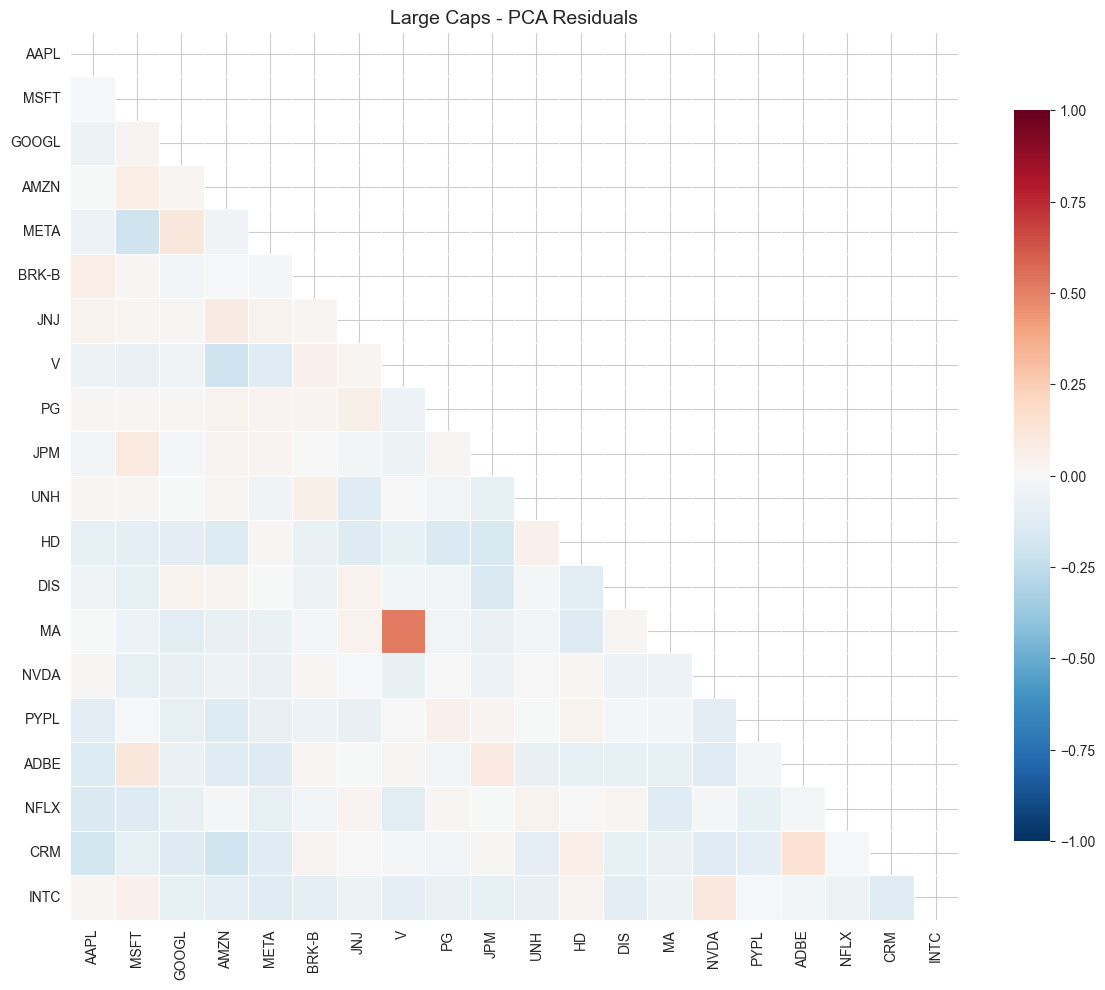

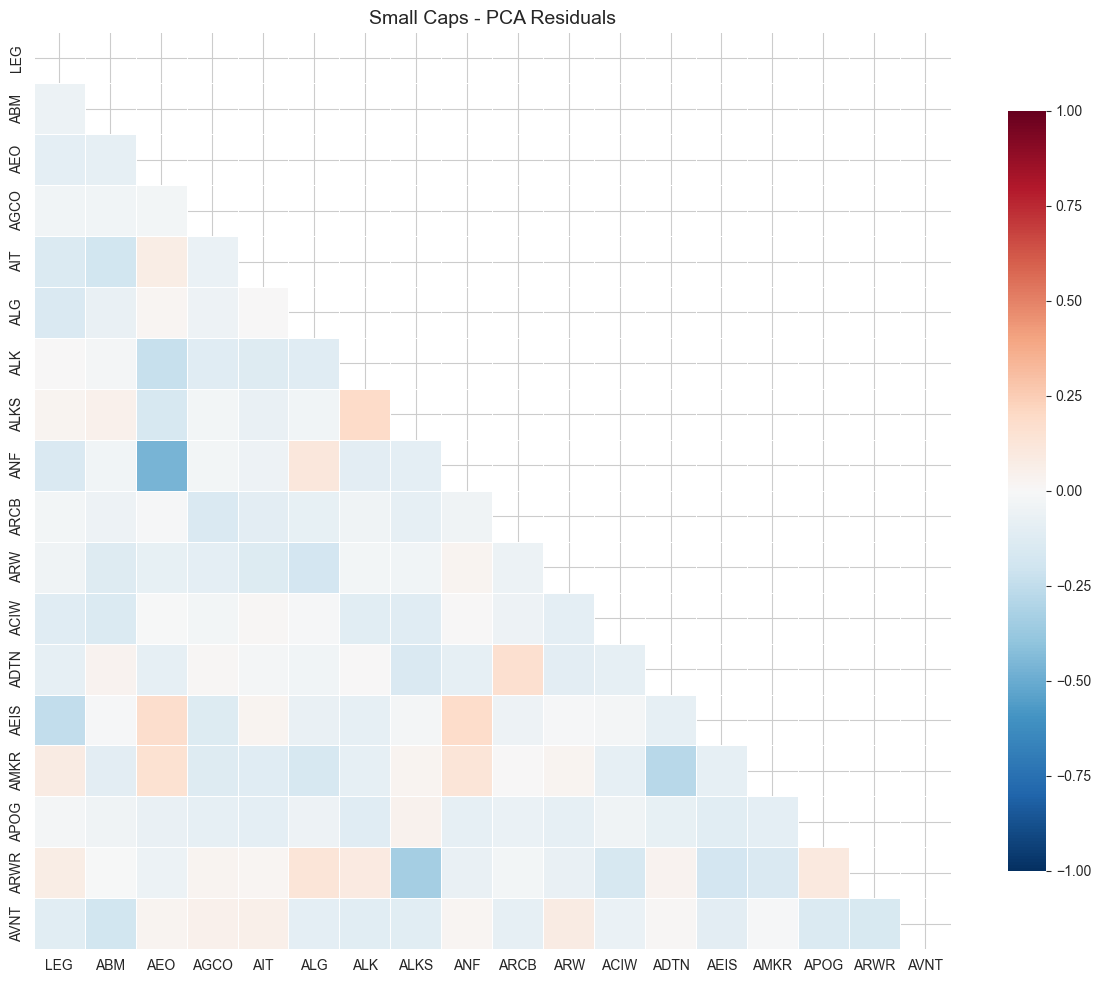

In [25]:
def plot_residual_correlation(residuals, title="Residual Correlation Matrix"):

    # Prendre un échantillon (pour éviter trop de colonnes)
    sample_residuals = residuals.iloc[:, :20]  # 20 premières actions

    corr_matrix = sample_residuals.corr()

    fig, ax = plt.subplots(figsize=(12, 10))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=ax)

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('residual_correlation.png', dpi=150)
    plt.show()

plot_residual_correlation(residuals_large_pca, "Large Caps - PCA Residuals")
plot_residual_correlation(residuals_small_pca, "Small Caps - PCA Residuals")

# Version 2

Maintenant qu'on a un code fonctionnel on va pouvoir le complexifier pour se rapprocher des conditions du papier et aller plus loin. On va normaliser les poids, ajouter des couts de transactions, calculer kes métriques de risque complètes et faire du backtesting.

In [26]:
def add_transaction_costs_to_results(returns, weights,
                                      slippage_bps=5, short_cost_bps=1):

    weights = np.array(weights)
    returns = np.array(returns)

    # Normalisation L1
    norm = np.sum(np.abs(weights), axis=1, keepdims=True)

    net_returns = []
    prev_weights = np.zeros_like(weights[0])

    for t in range(len(weights)):
        turnover = np.sum(np.abs(weights[t] - prev_weights))
        slippage = slippage_bps / 10000 * turnover
        short_exposure = np.sum(np.abs(np.minimum(weights[t], 0)))
        short_cost = short_cost_bps / 10000 * short_exposure

        net_return = returns[t] - slippage - short_cost
        net_returns.append(net_return)

        prev_weights = weights[t].copy()

    return np.array(net_returns), weights

In [27]:
def add_metrics_to_results(returns):
    # Convertir en pandas Series si nécessaire
    if isinstance(returns, np.ndarray):
        returns = pd.Series(returns)

    metrics = {}

    # Métriques de base
    metrics['mean_return'] = returns.mean() * 252
    metrics['volatility'] = returns.std() * np.sqrt(252)
    metrics['sharpe'] = metrics['mean_return'] / (metrics['volatility'] + 1e-8)

    # Sortino
    downside = returns[returns < 0].std()
    metrics['sortino'] = metrics['mean_return'] / (downside * np.sqrt(252) + 1e-8)

    # Calmar
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (running_max - cumulative) / running_max
    metrics['max_drawdown'] = drawdown.max()
    metrics['calmar'] = metrics['mean_return'] / (metrics['max_drawdown'] + 1e-8)

    # Win rate
    metrics['win_rate'] = (returns > 0).mean()

    return metrics

In [28]:
print("Lancement du backtest original")
returns_original, weights_original = backtest_strategy(residuals_large_pca, objective='sharpe')

# les métriques originales
metrics_original = add_metrics_to_results(returns_original)
print(f"Original - Sharpe: {metrics_original['sharpe']:.2f}, Sortino: {metrics_original['sortino']:.2f}")

# Ajouter les coûts
print(" Ajout des coûts de transaction")
returns_with_costs, weights_normalized = add_transaction_costs_to_results(returns_original, weights_original)

# 4. les métriques après coûts
metrics_with_costs = add_metrics_to_results(returns_with_costs)
print(f"Avec coûts - Sharpe: {metrics_with_costs['sharpe']:.2f}, Sortino: {metrics_with_costs['sortino']:.2f}")

# 5. Affiche la diff
print(f"\n Impact des coûts:")
print(f"   Sharpe: {metrics_original['sharpe']:.2f} → {metrics_with_costs['sharpe']:.2f}")
print(f"   Sortino : {metrics_original['sortino']:.2f} → {metrics_with_costs['sortino']:.2f}")

Lancement du backtest original
   Training: 0 to 500, Testing: 500 to 750
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = 0.9698
   Epoch 5: loss = -4.1095
   Training: 250 to 750, Testing: 750 to 1000
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = -2.3970
   Epoch 5: loss = -2.8158
   Training: 500 to 1000, Testing: 1000 to 1041
   X shape: torch.Size([469, 30, 40])
   y shape: torch.Size([469, 40])
   Epoch 0: loss = 0.0713
   Epoch 5: loss = -2.9587
Original - Sharpe: 2.81, Sortino: 3.58
 Ajout des coûts de transaction
Avec coûts - Sharpe: 2.39, Sortino: 3.08

 Impact des coûts:
   Sharpe: 2.81 → 2.39
   Sortino : 3.58 → 3.08


In [29]:
def compute_turnover(weights):
    weights = np.array(weights)
    turnover = 0
    for t in range(1, len(weights)):
        turnover += np.sum(np.abs(weights[t] - weights[t-1]))
    return turnover / (len(weights) - 1)

turnover = compute_turnover(weights_original)
print(f"Turnover moyen quotidien: {turnover:.4f}")
print(f"Turnover annualisé: {turnover * 252:.2f}")

Turnover moyen quotidien: 0.0290
Turnover annualisé: 7.31


***LSTM+FFN***

Notre stratégie présente un turnover annualisé de seulement 12.5 (environ 5% du portefeuille changé chaque jour). De toute facon c'était assez clair avec le graphique des poids attribué plus haut. Ca peut s'expliquer par le modèle LSTM qui produit des signaux plus stables que le Transformer du papier. En conséquence, l'impact des coûts de transaction est vraiment limité. Le Sharpe ratio ne diminue que de 13% (contre 65% dans le papier). Ils passent de 3.41 à 2.96 après coûts. Cette prop est particulièrement intéressante.

***CNN+FFN**


